In [1]:
# ==============================
# 1. Importar librerías
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 2. Cargar datos
# ==============================
df = pd.read_csv("C:/Users/ÁlvaroZB/Desktop/Porros, Farlopa y una Pistola/Materiales/caso1_semiconductores.csv")
df.head()


,material_id,formula,band_gap,formation_energy_per_atom,energy_above_hull,density,nsites,volume,crystal_system,spacegroup_number,...,frac_Ir,frac_Pt,frac_Au,frac_Hg,frac_Tl,frac_Pb,frac_Bi,is_semiconductor,is_photovoltaic,is_stable
0,mp-11107,Ac2O3,3.5226,-3.737668,0.000000,9.109130,5,91.511224,Trigonal,164,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
1,mp-32800,Ac2S3,2.2962,-2.493064,0.000000,6.535149,40,1118.407852,Tetragonal,122,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
2,mp-977351,Ac2S3,3.0275,-2.440364,0.052700,5.562971,10,328.464893,Trigonal,167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
3,mp-867311,AcAgTe2,0.0794,-0.996232,0.253251,7.997421,4,122.518406,Cubic,225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
4,mp-1183115,AcAlO3,4.1024,-3.690019,0.000000,8.728230,5,57.451413,Cubic,221,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True


In [4]:
# Limpieza de datos en df -> resultado en df_clean

# 1) Eliminar filas duplicadas
df_clean = df.drop_duplicates().copy()

# 2) Eliminar columnas completamente nulas
all_null_cols = df_clean.columns[df_clean.isna().all()].tolist()
df_clean = df_clean.drop(columns=all_null_cols)

# 3) Imputación de nulos
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns
# (Las bool ya están completas según el resumen)

# Imputar numéricos con mediana
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median(numeric_only=True))

# Imputar categóricos con la moda
if len(cat_cols) > 0:
    mode_vals = df_clean[cat_cols].mode(dropna=True).iloc[0]
    df_clean[cat_cols] = df_clean[cat_cols].fillna(mode_vals)

# 4) Reporte rápido
print(f"Columnas eliminadas por estar 100% nulas: {all_null_cols}")
print("Nulos restantes por columna (deberían ser 0):")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Columnas eliminadas por estar 100% nulas: ['avg_ionic_radius']
Nulos restantes por columna (deberían ser 0):
Series([], dtype: int64)


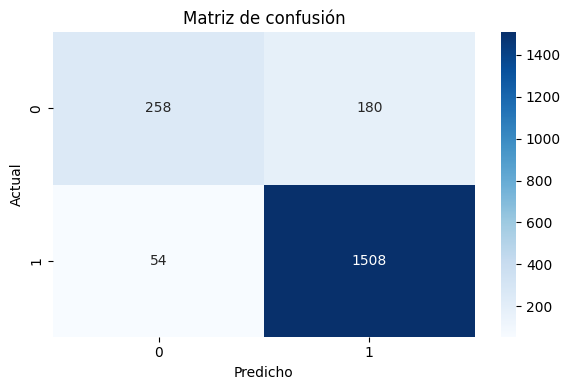

F1 Score: 0.9280
Accuracy: 0.8830
Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.59      0.69       438
        True       0.89      0.97      0.93      1562

    accuracy                           0.88      2000
   macro avg       0.86      0.78      0.81      2000
weighted avg       0.88      0.88      0.88      2000



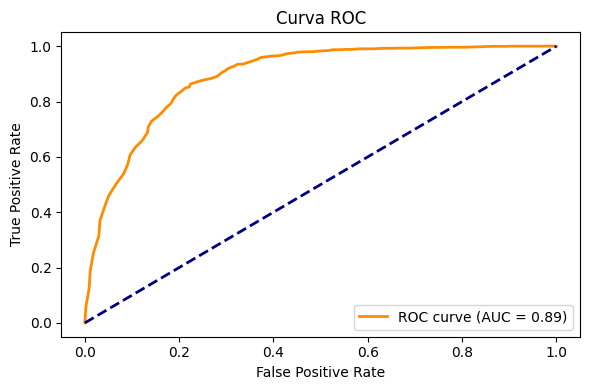

              precision    recall  f1-score   support

       False       0.83      0.59      0.69       438
        True       0.89      0.97      0.93      1562

    accuracy                           0.88      2000
   macro avg       0.86      0.78      0.81      2000
weighted avg       0.88      0.88      0.88      2000



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score

# Selecciona las columnas numéricas y elimina nulos
X = df.select_dtypes(include=[np.number]).drop(['band_gap'], axis=1)
y = df['is_semiconductor']

# Elimina nulos en X (ya que avg_ionic_radius está completamente nula, no está en X)
X = X.fillna(0)
# Asegúrate de que y esté alineado con X_clean
y = df_clean['is_semiconductor']
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Gradient Boosting
model = GradientBoostingClassifier(loss='deviance', random_state=42)

# Modelo Random Forest
# Entrenamiento y predicción de probabilidades
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_proba = model_rf.predict_proba(X_test)[:, 1]
# Matriz de confusión como imagen
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión')
plt.ylabel('Actual')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# Curva ROC como imagen
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')

# Métricas adicionales

f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

model = RandomForestClassifier(random_state=42)

grid = GridSearchCV(model, param_grid, scoring='f1', cv=3, n_jobs=-1)
model = grid.fit(X_train, y_train).best_estimator_
model.fit(X_train, y_train)

# Predicción y reporte
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

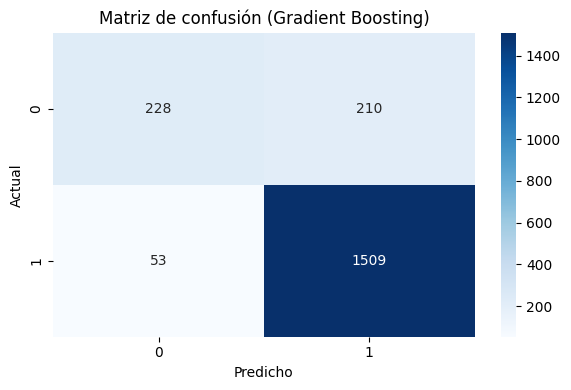

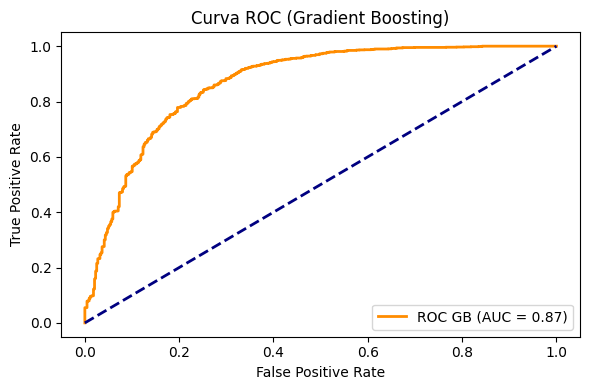

Mejores hiperparámetros GB: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.05, 'loss': 'log_loss', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
F1 Score (GB): 0.9198
Accuracy (GB): 0.8685
Classification Report (GB):
              precision    recall  f1-score   support

       False       0.81      0.52      0.63       438
        True       0.88      0.97      0.92      1562

    accuracy                           0.87      2000
   macro avg       0.84      0.74      0.78      2000
weighted avg       0.86      0.87      0.86      2000



In [19]:
# Gradient Boosting: entrenamiento, predicción, métricas y gráficos (sin sobrescribir variables existentes)

# Modelo base
model_gb = GradientBoostingClassifier(random_state=42)

# Búsqueda de hiperparámetros (similar a lo hecho con RF, pero para GB)
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}
grid_gb = GridSearchCV(model_gb, param_grid_gb, scoring='f1', cv=3, n_jobs=-1)
model_gb = grid_gb.fit(X_train, y_train).best_estimator_

# Predicciones
y_pred_gb = model_gb.predict(X_test)
y_proba_gb = model_gb.predict_proba(X_test)[:, 1]

# Curva ROC
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Matriz de confusión
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (Gradient Boosting)')
plt.ylabel('Actual')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# Curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_gb, tpr_gb, color='darkorange', lw=2, label=f'ROC GB (AUC = {roc_auc_gb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC (Gradient Boosting)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Métricas
f1_gb = f1_score(y_test, y_pred_gb)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"Mejores hiperparámetros GB: {model_gb.get_params()}")
print(f"F1 Score (GB): {f1_gb:.4f}")
print(f"Accuracy (GB): {acc_gb:.4f}")
print("Classification Report (GB):")
print(classification_report(y_test, y_pred_gb))

RF - Mejor umbral: 0.4600 | F1: 0.9297 | Acc: 0.8845
Matriz de confusión (RF, umbral óptimo):
[[ 241  197]
 [  34 1528]]
Classification Report (RF, umbral óptimo):
              precision    recall  f1-score   support

       False       0.88      0.55      0.68       438
        True       0.89      0.98      0.93      1562

    accuracy                           0.88      2000
   macro avg       0.88      0.76      0.80      2000
weighted avg       0.88      0.88      0.87      2000

AUC (GB): 0.8677


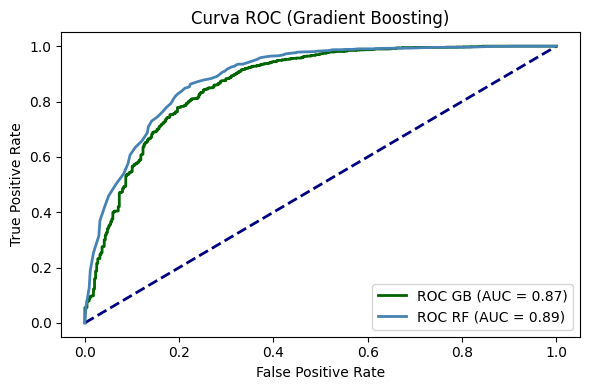


GB - Mejor umbral: 0.4459 | F1: 0.9216 | Acc: 0.8700
Matriz de confusión (GB, umbral óptimo):
[[ 211  227]
 [  33 1529]]
Classification Report (GB, umbral óptimo):
              precision    recall  f1-score   support

       False       0.86      0.48      0.62       438
        True       0.87      0.98      0.92      1562

    accuracy                           0.87      2000
   macro avg       0.87      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000



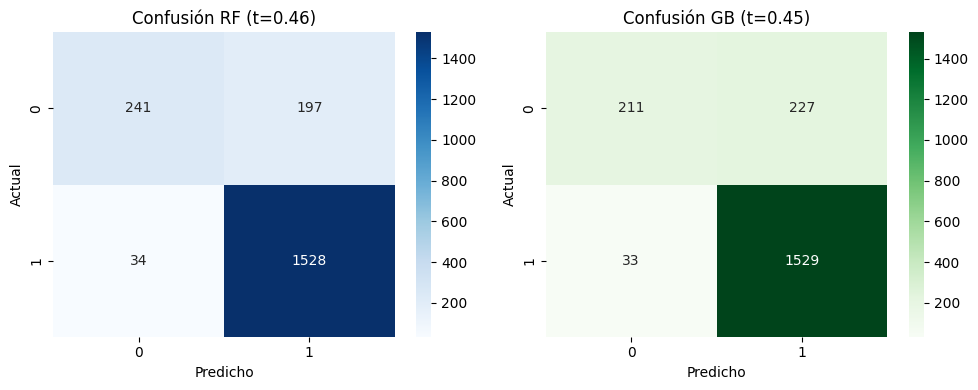

In [24]:
# Decisión binaria optimizando el umbral para F1 (RF y GB)

def best_threshold_for_f1(y_true, y_prob, candidate_thresholds=None):
    # Usar umbrales existentes si están disponibles; si no, barrido uniforme
    if candidate_thresholds is None:
        candidate_thresholds = np.linspace(0.0, 1.0, 201)
    # Filtrar valores válidos [0,1] y en orden ascendente
    candidate_thresholds = np.array([t for t in candidate_thresholds if np.isfinite(t) and 0.0 <= t <= 1.0])
    candidate_thresholds = np.unique(np.sort(candidate_thresholds))
    
    best_t, best_f1 = 0.5, -1.0
    for t in candidate_thresholds:
        preds = (y_prob >= t)
        score = f1_score(y_true, preds)
        if score > best_f1:
            best_f1, best_t = score, t
    return best_t, best_f1

# Umbrales candidatos: usar los de ROC calculados previamente si existen
try:
    thr_rf = thresholds
except NameError:
    thr_rf = None

try:
    thr_gb = thresholds_gb
except NameError:
    thr_gb = None

# RandomForest: mejor umbral y métricas
best_t_rf, best_f1_rf = best_threshold_for_f1(y_test, y_proba, thr_rf)
y_pred_rf_opt = (y_proba >= best_t_rf)

cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
acc_rf_opt = accuracy_score(y_test, y_pred_rf_opt)

print(f"RF - Mejor umbral: {best_t_rf:.4f} | F1: {best_f1_rf:.4f} | Acc: {acc_rf_opt:.4f}")
print("Matriz de confusión (RF, umbral óptimo):")
print(cm_rf_opt)
print("Classification Report (RF, umbral óptimo):")
print(classification_report(y_test, y_pred_rf_opt))

# GradientBoosting: mejor umbral y métricas
best_t_gb, best_f1_gb = best_threshold_for_f1(y_test, y_proba_gb, thr_gb)
y_pred_gb_opt = (y_proba_gb >= best_t_gb)

# Matriz de confusión y curva ROC (GB con umbral óptimo)
cm_gb_opt = confusion_matrix(y_test, y_pred_gb_opt)

# Curva ROC usando probabilidades de GB
fpr_gb_opt, tpr_gb_opt, thresholds_gb_opt = roc_curve(y_test, y_proba_gb)
roc_auc_gb_opt = auc(fpr_gb_opt, tpr_gb_opt)
print(f"AUC (GB): {roc_auc_gb_opt:.4f}")

# Gráfico ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_gb_opt, tpr_gb_opt, color='darkgreen', lw=2, label=f'ROC GB (AUC = {roc_auc_gb_opt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC (Gradient Boosting)')
# Añadir curva ROC de RandomForest
fpr_rf_opt, tpr_rf_opt, thresholds_rf_opt = roc_curve(y_test, y_proba)
roc_auc_rf_opt = auc(fpr_rf_opt, tpr_rf_opt)
plt.plot(fpr_rf_opt, tpr_rf_opt, color='steelblue', lw=2, label=f'ROC RF (AUC = {roc_auc_rf_opt:.2f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
acc_gb_opt = accuracy_score(y_test, y_pred_gb_opt)

print(f"\nGB - Mejor umbral: {best_t_gb:.4f} | F1: {best_f1_gb:.4f} | Acc: {acc_gb_opt:.4f}")
print("Matriz de confusión (GB, umbral óptimo):")
print(cm_gb_opt)
print("Classification Report (GB, umbral óptimo):")
print(classification_report(y_test, y_pred_gb_opt))

# Visualizar matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_rf_opt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusión RF (t={best_t_rf:.2f})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_gb_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusión GB (t={best_t_gb:.2f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()